cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0
fake-and-real-news-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  fake-and-real-news-dataset.zip
replace Fake.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: Shape of dataset: (3000, 2)

First 5 Rows:

                                                   title label
22216  Ben Stein Calls Out 9th Circuit Court: Committ...  Fake
4436   Trump drops Steve Bannon from National Securit...  Real
1526   Puerto Rico expects U.S. to lift Jones Act shi...  Real
1377    OOPS: Trump Just Accidentally Confirmed He Le...  Fake
8995   Donald Trump heads for Scotland to reopen a go...  Real

========== Correct Predictions ==========

Actual: Fake | Predicted: Fake
Actual: Fake | Predicted: Fake
Actual: Fake

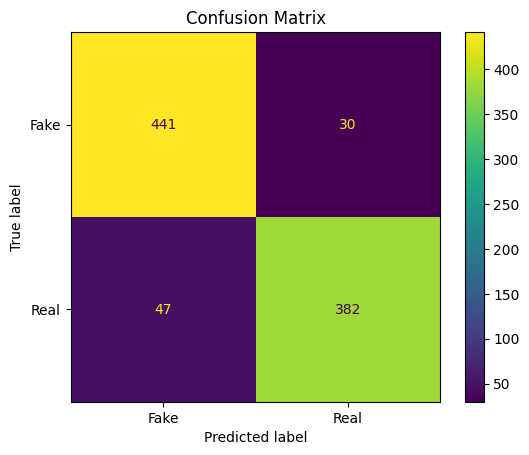

In [2]:
# ============================================
# Multinomial Naive Bayes using Fake News Dataset
# With Confusion Matrix
# Faster Version for Lab Assignment
# ============================================


# ============================================
# STEP 1: Setup Kaggle API
# ============================================

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


# ============================================
# STEP 2: Download Dataset
# ============================================

!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset


# ============================================
# STEP 3: Unzip Dataset
# ============================================

!unzip fake-and-real-news-dataset.zip


# ============================================
# STEP 4: Import Libraries
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# ============================================
# STEP 5: Load Dataset
# ============================================

fake = pd.read_csv("Fake.csv")

real = pd.read_csv("True.csv")


# ============================================
# STEP 6: Create Labels
# ============================================

fake["label"] = "Fake"

real["label"] = "Real"


# ============================================
# STEP 7: Combine Dataset
# ============================================

data = pd.concat([fake, real])


# ============================================
# STEP 8: Reduce Dataset Size (Faster Training)
# ============================================

data = data.sample(3000, random_state=42)


# ============================================
# STEP 9: Keep Required Columns Only
# ============================================

data = data[['title', 'label']]

print("Shape of dataset:", data.shape)

print("\nFirst 5 Rows:\n")

print(data.head())


# ============================================
# STEP 10: Features and Target
# ============================================

X = data["title"]

y = data["label"]


# ============================================
# STEP 11: Convert Text into Numerical Form
# ============================================

vectorizer = CountVectorizer(
    stop_words='english',
    max_features=3000
)

X_vectorized = vectorizer.fit_transform(X)


# ============================================
# STEP 12: Split Dataset
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.3,
    random_state=42
)


# ============================================
# STEP 13: Train Multinomial Naive Bayes
# ============================================

model = MultinomialNB()

model.fit(X_train, y_train)


# ============================================
# STEP 14: Predictions
# ============================================

y_pred = model.predict(X_test)


# ============================================
# STEP 15: Correct Predictions
# ============================================

print("\n========== Correct Predictions ==========\n")

count = 0

for actual, predicted in zip(y_test, y_pred):

    if actual == predicted and count < 10:

        print(
            f"Actual: {actual} | "
            f"Predicted: {predicted}"
        )

        count += 1


# ============================================
# STEP 16: Wrong Predictions
# ============================================

print("\n========== Wrong Predictions ==========\n")

count = 0

for actual, predicted in zip(y_test, y_pred):

    if actual != predicted and count < 10:

        print(
            f"Actual: {actual} | "
            f"Predicted: {predicted}"
        )

        count += 1


# ============================================
# STEP 17: Accuracy
# ============================================

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)


# ============================================
# STEP 18: Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")

print(cm)


# ============================================
# STEP 19: Display Confusion Matrix
# ============================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)
# ============================================
# STEP 20: Classification Report
# ============================================

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))
disp.plot()

plt.title("Confusion Matrix")

plt.show()